# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print((users.isna().mean() * 100).round(2))

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print((usage.isna().mean() * 100).round(2))

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
# Comentario:
# En users se revisaron los valores faltantes por columna. Si alguna columna tiene menos de 5% de nulos,
# se puede conservar y evaluar imputación o dejar los nulos si no afectan el análisis.
# Si alguna columna tiene entre 5% y 30%, conviene investigar antes de imputar.
# Si alguna columna tiene más de 80% de nulos, normalmente se ignora o elimina porque aporta poca información.
#
# En usage se revisaron los valores faltantes por columna. Las columnas con pocos nulos pueden imputarse
# o conservarse según su importancia. Si los nulos están en variables clave como duración o mensajes,
# deben analizarse antes de calcular estadísticas.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


# La columna user_id es un identificador único de cliente, por lo que no debe interpretarse como variable estadística.
# La columna age tiene 4,000 registros, pero muestra un valor mínimo de -999, lo cual es un sentinel o valor inválido.
# La edad válida parece ir hasta 79 años, pero antes de analizar se debe reemplazar -999 por valor nulo.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


# Las columnas id y user_id son identificadores, por lo que no deben analizarse como variables de consumo.
# La columna duration tiene 17,924 registros no nulos y valores entre 0 y 120; se debe revisar si 0 representa llamadas no contestadas o registros válidos.
# La columna length tiene 22,104 registros no nulos y valores entre 0 y 1,490; el máximo es muy alto frente a la mediana de 50, por lo que puede ser un outlier.
# También hay valores faltantes en duration y length, lo cual puede estar relacionado con el tipo de evento: llamadas usan duration y mensajes usan length.

In [18]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts(dropna=False))

# reemplazar sentinels detectados por valores nulos
users['city'] = users['city'].replace('?', np.nan)
users['age'] = users['age'].replace(-999, np.nan)

# explorar columnas categóricas de users después de limpiar
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores únicos en {col}:")
    print(users[col].value_counts(dropna=False))



Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

Valores únicos en plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


# La columna city muestra ciudades válidas como Bogotá, CDMX, Medellín, GDL, Cali y MTY.
# También contiene 469 valores nulos y 96 registros con "?", los cuales deben tratarse como valores faltantes o inválidos.
# Antes del análisis por ciudad, conviene reemplazar "?" por NaN y decidir si se imputan o se dejan como categoría desconocida.
# La columna plan tiene dos categorías válidas: Basico y Premium.
# No se observan valores nulos ni categorías inválidas en esta columna.
# Esta variable puede usarse para segmentar clientes por tipo de plan contratado.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

# La columna type contiene dos categorías válidas: text y call.
# Hay más registros de mensajes que de llamadas: 22,092 textos frente a 17,908 llamadas.
# No se observan valores nulos ni categorías inválidas en esta columna, por lo que puede usarse para separar el análisis de duración de llamadas y longitud de mensajes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
• En users encontré dos problemas principales: la columna age tenía el valor -999, que no representa una edad válida, y la columna city tenía registros con “?”, que funcionan como sentinel de ciudad desconocida.

• La acción recomendada es reemplazar age = -999 por NaN y reemplazar city = “?” por NaN para tratarlos como valores faltantes.

• Después de la limpieza, city quedó con 565 valores nulos. Conviene conservarlos como dato faltante o crear una categoría “Desconocida” si se necesita analizar distribución por ciudad.

• En plan no encontré valores inválidos. Solo aparecen las categorías Basico y Premium, por lo que puede usarse para segmentación.

• En usage no se detectaron sentinels claros en type, ya que solo aparecen call y text. En duration y length hay valores en 0 y valores extremos, pero deben revisarse en el paso de outliers antes de decidir si son errores o comportamientos reales.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [21]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

# En reg_date se observan registros de 2022, 2023, 2024 y 40 registros en 2026.
# Como el proyecto indica que los datos llegan hasta 2024, el año 2026 está fuera de rango.
# La acción recomendada es marcar esas fechas como NaT o excluir esos 40 registros del análisis temporal.

In [22]:
# En date de usage casi todos los registros pertenecen a 2024, con 39,950 registros válidos.
# También aparecen 50 valores NaN, lo cual indica fechas faltantes o fechas que no pudieron convertirse correctamente.
# La acción recomendada es excluir esos 50 registros del análisis temporal, aunque pueden conservarse para otros análisis no basados en fecha


2024.0    39950
NaN          50
Name: date, dtype: int64

En date se observa que casi todos los registros de uso corresponden al año 2024, con 39,950 registros válidos. También aparecen 50 valores sin fecha, representados como NaN, lo cual indica fechas faltantes o registros que no pudieron convertirse correctamente. Como el análisis se basa en el comportamiento registrado hasta 2024, usaremos los registros con fecha válida de 2024 y excluiremos los valores NaN cuando el análisis dependa de la fecha.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
# Se detectaron fechas fuera de rango en reg_date: 40 registros aparecen en 2026.
# Como el análisis considera datos hasta 2024, esas fechas no deben usarse para análisis temporal.
# En usage se detectaron 50 fechas nulas, por lo que deben excluirse de análisis por fecha.
# La acción recomendada es convertir fechas fuera de rango a NaT y documentar los registros afectados.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    3945.000000
mean       48.137896
std        17.812830
min        18.000000
25%        33.000000
50%        48.000000
75%        64.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [25]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
)

duration,False,True,All
type,,,
call,17908,0,17908
text,16,22076,22092
All,17924,22076,40000


In [27]:
# Verificación MAR en usage para length
pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
)

length,False,True,All
type,,,
call,12,17896,17908
text,22092,0,22092
All,22104,17896,40000


Los nulos en duration y length dependen principalmente de la columna type. En los registros de tipo call, duration contiene la duración de la llamada y length queda nulo porque no aplica. En los registros de tipo text, length contiene la longitud del mensaje y duration queda nulo porque no aplica.

También se detectaron algunos registros inconsistentes: 16 textos tienen duration registrada y 12 llamadas tienen length registrada. Estos casos deben revisarse porque no siguen la lógica esperada del dataset.

La acción recomendada es dejar los nulos como están, analizar duration solo para llamadas y length solo para mensajes. Para los registros inconsistentes, conviene marcarlos o excluirlos del análisis específico de llamadas y mensajes para evitar sesgos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3945.000000,3999.000000,3999.000000,3999.000000
mean,48.137896,5.524381,4.478120,23.317054
std,17.812830,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,64.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [32]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True).mul(100).round(2)


Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

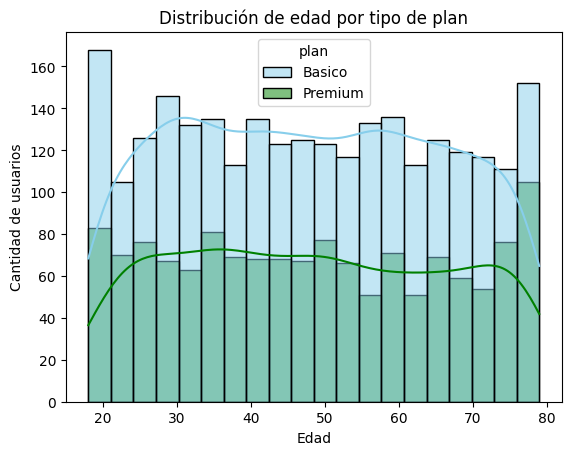

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
La distribución de edad es amplia y cubre aproximadamente de 18 a 79 años. No se observa una concentración clara en un grupo específico, por lo que la edad parece estar distribuida de forma relativamente uniforme. En ambos planes hay usuarios de casi todos los rangos de edad, aunque el plan Basico tiene mayor volumen total de usuarios que Premium.

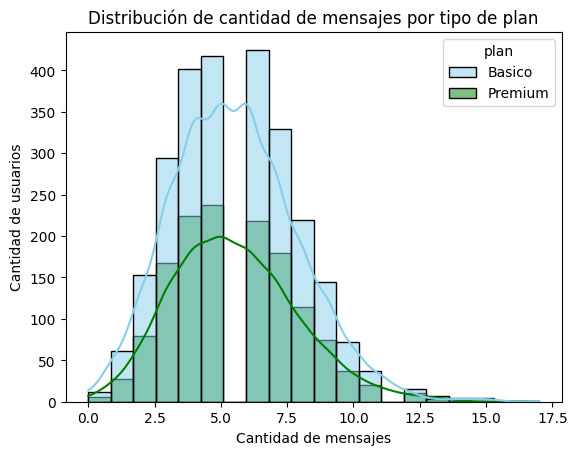

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de cantidad de mensajes por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
La distribución de cant_mensajes se concentra principalmente entre 3 y 8 mensajes por usuario. Tiene una ligera cola hacia la derecha, ya que existen pocos usuarios con más de 10 mensajes. Ambos planes muestran una forma similar, aunque Basico concentra más usuarios por su mayor tamaño de base.

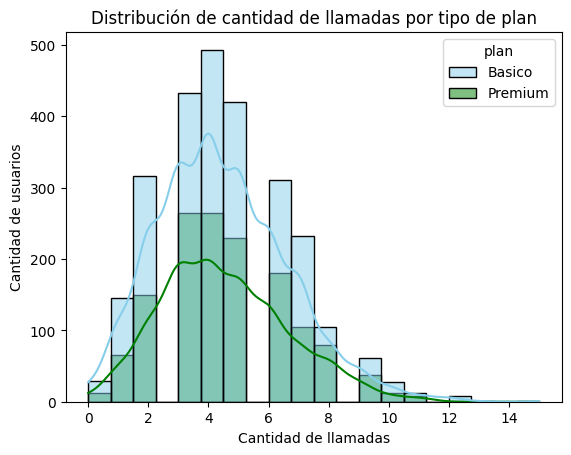

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de cantidad de llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
La distribución de cant_llamadas se concentra principalmente entre 3 y 6 llamadas por usuario. La forma es similar entre Basico y Premium, sin una diferencia clara en el patrón de uso por plan. Hay pocos usuarios con más de 10 llamadas, lo que sugiere posibles casos de alto consumo.

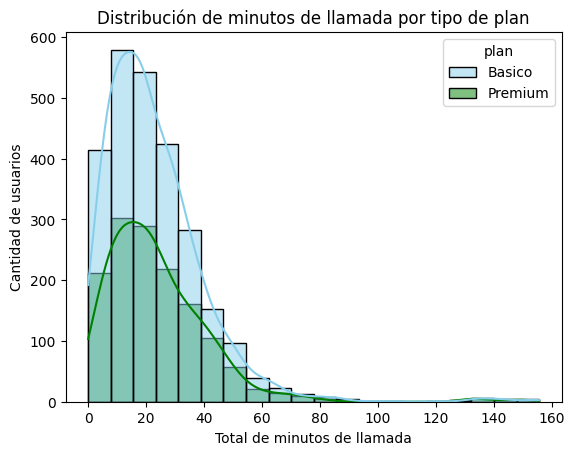

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de minutos de llamada por tipo de plan")
plt.xlabel("Total de minutos de llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
La distribución de cant_minutos_llamada está sesgada hacia la derecha. La mayoría de los usuarios acumula menos de 40 minutos, pero existen usuarios con valores mucho más altos, incluso superiores a 100 minutos. Estos valores extremos deben revisarse en el análisis de outliers, ya que podrían representar usuarios intensivos o registros atípicos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

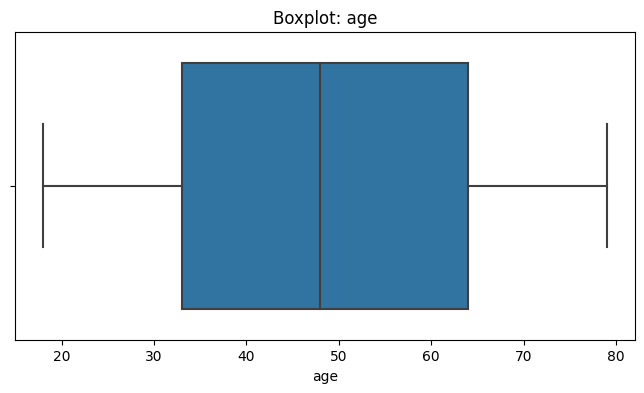

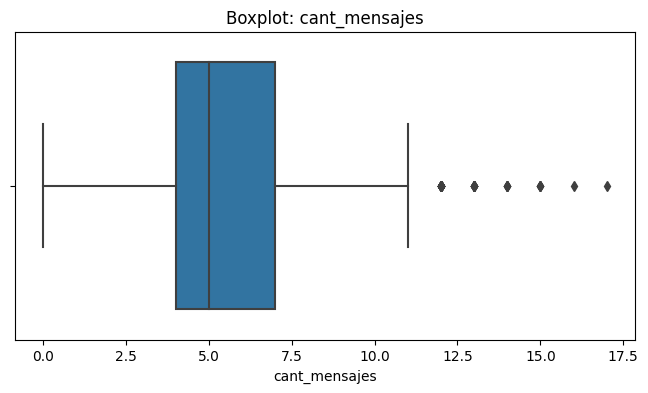

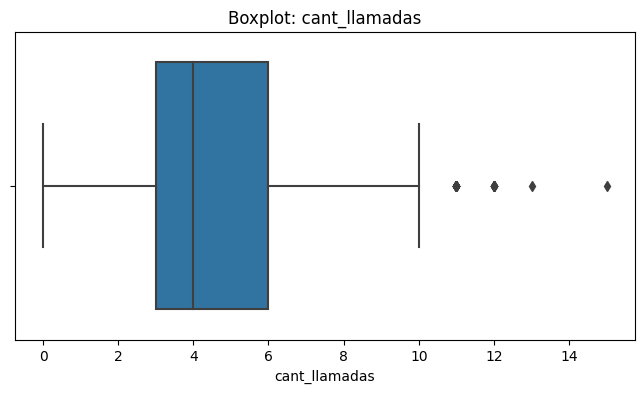

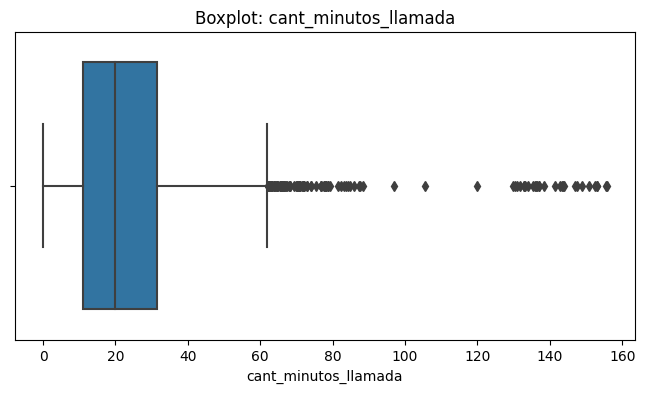

In [37]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
Age: no presenta outliers visibles. Después de corregir el sentinel -999, la edad queda dentro de un rango razonable, aproximadamente entre 18 y 79 años.

cant_mensajes: presenta outliers superiores. El límite superior por IQR es 11.5 y el máximo observado es 17. Se detectan 46 usuarios con consumo de mensajes por encima del rango típico.

cant_llamadas: presenta outliers superiores. El límite superior por IQR es 10.5 y el máximo observado es 15. Se detectan 30 usuarios con más llamadas que la mayoría.

cant_minutos_llamada: presenta outliers superiores claros. El límite superior por IQR es 61.86 y el máximo observado es 155.69. Se detectan 109 usuarios con consumo de minutos mucho mayor al comportamiento típico.

In [38]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    
    outliers = user_profile[user_profile[col] > limite_superior]
    
    print(f"\nVariable: {col}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Límite superior: {limite_superior}")
    print(f"Máximo: {user_profile[col].max()}")
    print(f"Cantidad de outliers superiores: {outliers.shape[0]}")




Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Máximo: 17.0
Cantidad de outliers superiores: 46

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Máximo: 15.0
Cantidad de outliers superiores: 30

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite superior: 61.8575
Máximo: 155.69
Cantidad de outliers superiores: 109


In [39]:
# Revisar los límites superiores y el max para tomar decisión
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes: se recomienda mantener los outliers. Aunque superan el límite estadístico de 11.5 mensajes, el máximo de 17 no parece un error de registro. Puede representar usuarios con mayor uso de mensajería.

cant_llamadas: se recomienda mantener los outliers. El máximo de 15 llamadas es superior al comportamiento típico, pero sigue siendo un valor posible dentro del uso normal del servicio. Puede ayudar a identificar usuarios con mayor necesidad de llamadas.

cant_minutos_llamada: se recomienda mantener los outliers y analizarlos como segmento de alto consumo. Aunque el máximo de 155.69 minutos está muy por encima del límite de 61.86, puede representar usuarios intensivos. No conviene eliminarlos sin evidencia de error, porque pueden aportar información comercial relevante para diseñar mejores planes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [42]:

# distribución porcentual de grupos de uso
user_profile['grupo_uso'].value_counts(normalize=True).mul(100).round(2)

Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)


In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

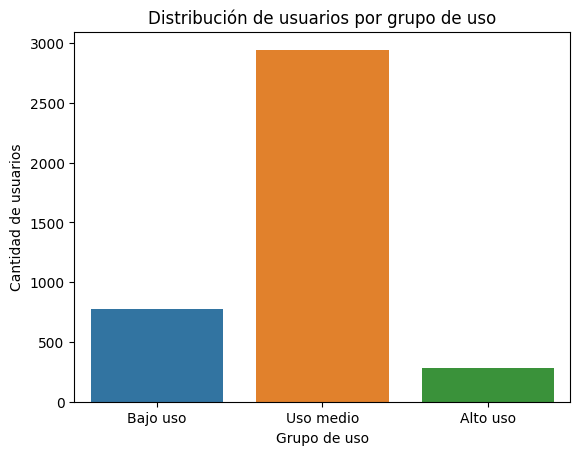

In [45]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

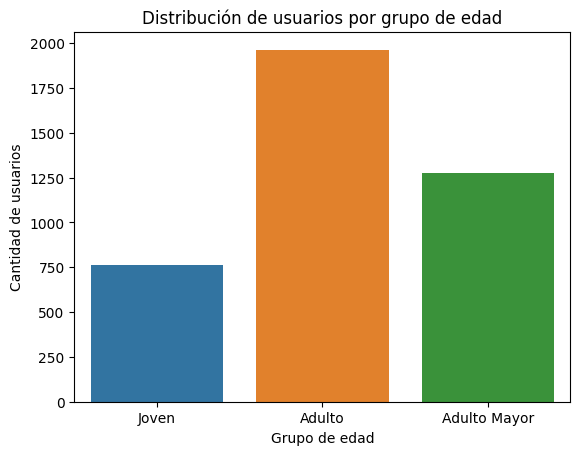

In [46]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

• En users se detectó el sentinel -999 en la columna age. Este valor no representa una edad válida, por lo que se reemplazó con la mediana para evitar sesgos en el análisis por edad.

• En city se detectaron 96 registros con “?”, además de valores nulos existentes. Después de reemplazar “?” por valores nulos, la columna city quedó con 565 registros faltantes. Esto representa información incompleta sobre la ubicación del cliente, por lo que no debe usarse sin considerar esa limitación.

• En reg_date se detectaron 40 registros con año 2026. Como el proyecto considera datos hasta 2024, estas fechas se marcaron como fuera de rango y no deben usarse para análisis temporal.

• En usage se detectaron 50 valores nulos en date. Estos registros deben excluirse cuando el análisis dependa de fechas.

• En duration y length los nulos dependen principalmente de type. Para llamadas, duration aplica y length queda nulo. Para mensajes, length aplica y duration queda nulo. Se detectaron algunos registros inconsistentes, pero la regla general del dataset se mantiene.


🔍 **Segmentos por Edad**
• Se crearon tres grupos de edad: Joven, Adulto y Adulto Mayor.

• El grupo con mayor cantidad de usuarios es Adulto, seguido por Adulto Mayor y después Joven.

• Esto indica que la base de clientes se concentra principalmente en usuarios adultos, por lo que las estrategias comerciales principales deben considerar hábitos de consumo de este grupo.

• El segmento Joven es menor en tamaño, pero puede ser relevante para campañas de adquisición o planes enfocados en comunicación digital y mensajes.


📊 **Segmentos por Nivel de Uso**

• La mayoría de los usuarios pertenece a Uso medio, con 73.58% del total.

• El segmento Bajo uso representa 19.45%. Estos clientes podrían tener baja adopción del servicio, bajo interés o un plan que no se ajusta a sus necesidades.

• El segmento Alto uso representa 6.98%. Aunque es el grupo más pequeño, es comercialmente relevante porque concentra usuarios con mayor demanda de llamadas o mensajes.

• Esta segmentación ayuda a diferenciar acciones: retención y upselling para alto uso, activación para bajo uso y optimización de beneficios para uso medio.

➡️ Esto sugiere que ...

• ConnectaTel tiene una base de clientes mayoritariamente de uso medio, lo cual indica un comportamiento estable y relativamente predecible.

• Los usuarios de alto uso no deben tratarse como errores solo por aparecer como outliers. En muchos casos representan clientes intensivos con valor comercial potencial.

• Los usuarios de bajo uso requieren atención porque pueden estar subutilizando el plan, tener baja satisfacción o estar en riesgo de churn.

• La edad y el nivel de uso permiten construir segmentos accionables para mejorar la oferta comercial, personalizar campañas y ajustar beneficios por tipo de cliente.

💡 **Recomendaciones**

• Mantener los outliers de uso en el análisis, especialmente en cant_minutos_llamada, porque pueden representar usuarios intensivos y oportunidades de planes premium.

• Crear campañas de activación para usuarios de Bajo uso, enfocadas en explicar beneficios del plan, promociones temporales o migración a planes más adecuados.

• Diseñar beneficios diferenciados para usuarios de Alto uso, como paquetes con más minutos, mensajes adicionales o alertas de consumo.

• Analizar el churn por grupo_uso y grupo_edad para identificar si los clientes de bajo uso tienen mayor probabilidad de abandonar el servicio.

• Mejorar la calidad de captura de city y reg_date, ya que los valores faltantes o fuera de rango limitan el análisis geográfico y temporal.

• Usar user_profile como tabla base para futuros análisis, porque integra datos del cliente, plan contratado, uso real, grupo de edad y grupo de uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`